ANÁLISIS DE ESTABILIDAD — TEOREMA DE HARTMAN-GROBMAN

P1 (Diabetes)
  Coordenadas : (697.22, 0.0000, 0.0000)
  Eigenvalores: [-432.41    -1.44    -0.641]
  Tipo        : Nodo Estable

P2 (Silla)
  Coordenadas : (250.00, 3.5770, 47.2700)
  Eigenvalores: [-4.311451e+02 -5.324000e+00  4.370000e-02]
  Tipo        : Punto de Silla

P3 (Homeostasis)
  Coordenadas : (100.00, 11.9440, 358.6700)
  Eigenvalores: [-4.203259e+02 -2.210940e+01 -1.440000e-02]
  Tipo        : Nodo Estable

Integrando trayectorias locales y globales...
Integración completada.



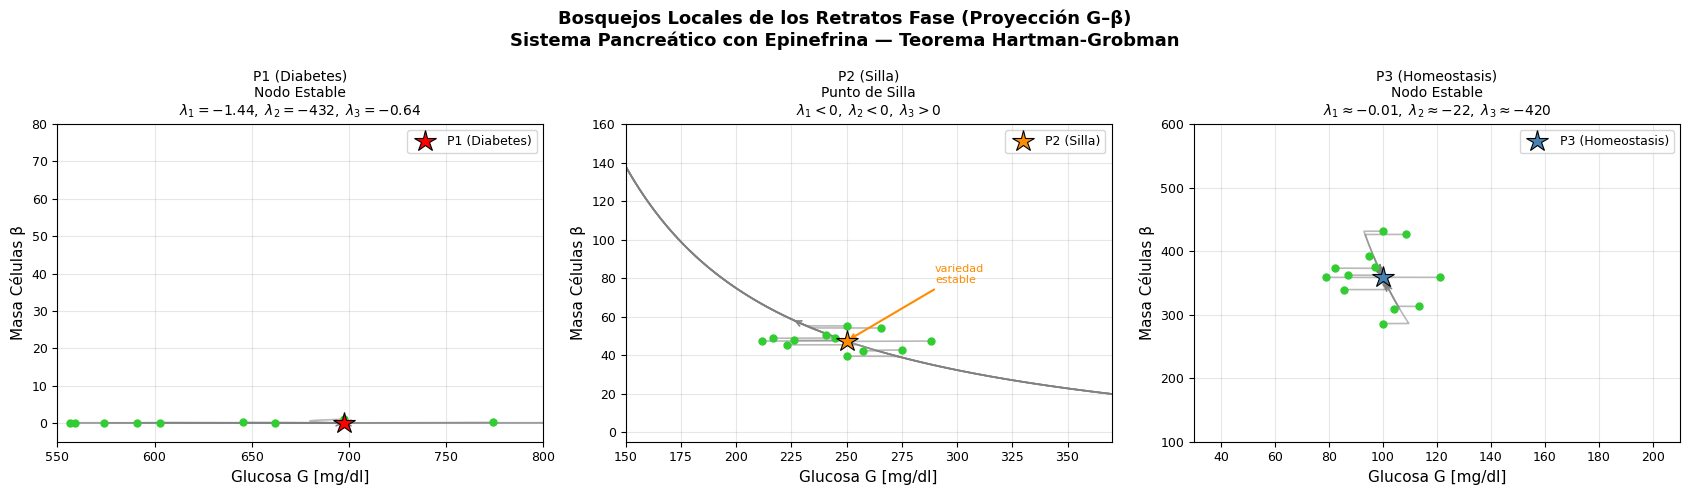

Figura 1 guardada.


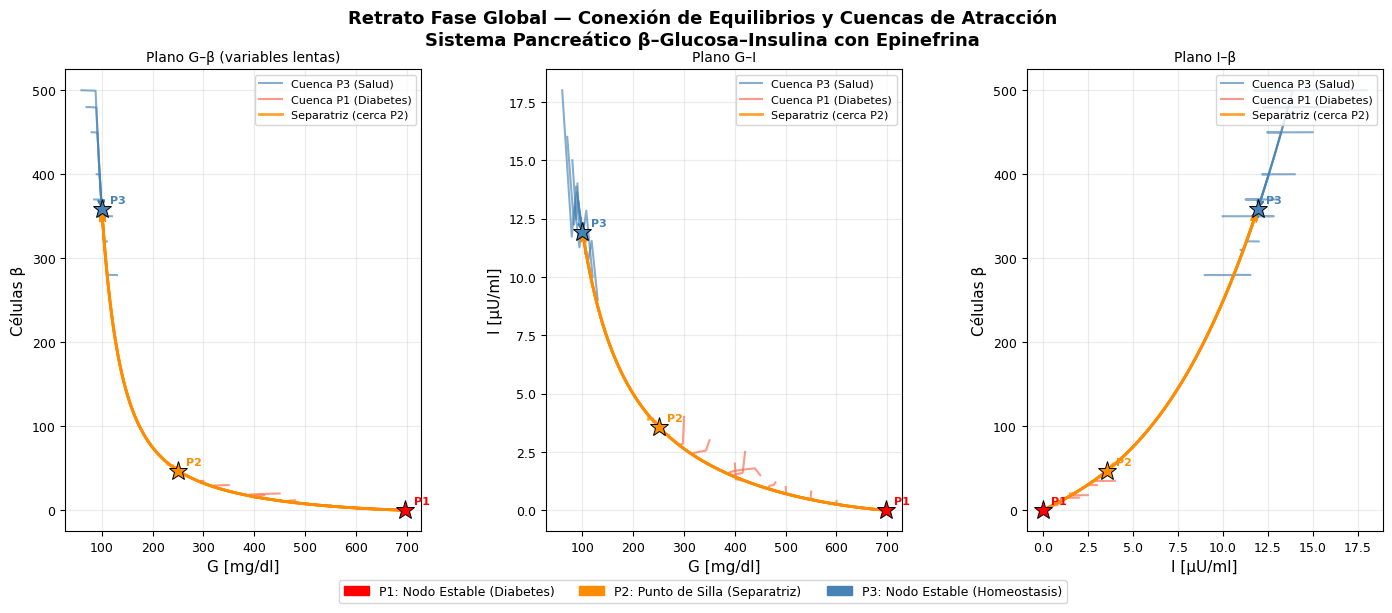

Figura 2 guardada.


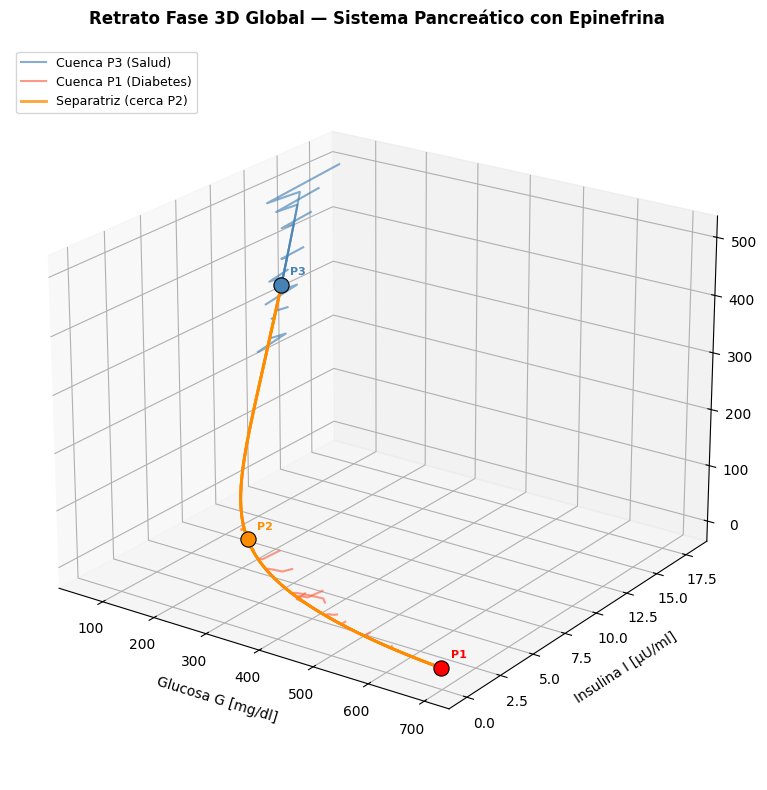

Figura 3 guardada.

✓ Todas las figuras generadas correctamente.


In [1]:
"""
Fase 3 — Retratos Fase: Sistema Pancreático β-Insulina-Glucosa
Análisis Cualitativo No Lineal
MA2008B.602 | ITESM Campus Ciudad de México
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import eig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────────────────────
# 1. PARÁMETROS (Tabla 2 del reto / Cuadro 1 del informe)
# ─────────────────────────────────────────────────────────────
p = {
    'R0': 864.0,    'Ge': 140.0,    'EGO': 1.44,
    'SI': 0.72,     'sigma': 43.2,  'alpha': 20000.0,
    'rho': 0.41,    'k': 432.0,     'd0': 0.06,
    'r1': 0.84e-3,  'r2': 0.24e-5
}
# ─────────────────────────────────────────────────────────────
# 2. CAMPO VECTORIAL
# ─────────────────────────────────────────────────────────────
def sistema(t, state, p):
    G, I, beta = state
    # Protección del ortante positivo (evita artefactos numéricos)
    G    = max(G, 1e-9)
    I    = max(I, 0.0)
    beta = max(beta, 0.0)

    dG   = p['R0'] + p['Ge'] - (p['EGO'] + p['SI']*I) * G
    dI   = (beta * p['sigma'] * G**2) / (p['alpha'] + G**2) \
           - (p['rho'] + p['k']) * I        
    dbeta = (-p['d0'] + p['r1']*G - p['r2']*G**2) * beta
    return [dG, dI, dbeta]

# ─────────────────────────────────────────────────────────────
# 3. JACOBIANA ANALÍTICA
# ─────────────────────────────────────────────────────────────
def jacobiana(G, I, beta, p):
    """Matriz Jacobiana evaluada en (G, I, beta)."""
    a = p['alpha']
    J = np.array([
        [ -(p['SI']*I + p['EGO']),
          -p['SI']*G,
          0 ],
        [ 2*beta*p['sigma']*G*a / (G**2 + a)**2,
          -(p['rho'] + p['k']),
          p['sigma']*G**2 / (G**2 + a) ],
        [ beta*(p['r1'] - 2*p['r2']*G),
          0,
          -p['d0'] + p['r1']*G - p['r2']*G**2 ]   # = 0 en P2, P3
    ])
    return J

# ─────────────────────────────────────────────────────────────
# 4. PUNTOS DE EQUILIBRIO
# ─────────────────────────────────────────────────────────────
eq_pts = {
    'P1 (Diabetes)':     np.array([697.22,  0.0,    0.0   ]),
    'P2 (Silla)':        np.array([250.0,   3.577,  47.27 ]),
    'P3 (Homeostasis)':  np.array([100.0,  11.944, 358.67 ]),
}
eq_colors = {'P1 (Diabetes)': 'red', 'P2 (Silla)': 'darkorange',
             'P3 (Homeostasis)': 'steelblue'}

# ─────────────────────────────────────────────────────────────
# 5. ANÁLISIS DE EIGENVALORES
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS DE ESTABILIDAD — TEOREMA DE HARTMAN-GROBMAN")
print("=" * 60)
eigen_data = {}
for name, eq in eq_pts.items():
    J  = jacobiana(*eq, p)
    vals, vecs = eig(J)
    vals_r = np.sort(vals.real)
    eigen_data[name] = (vals_r, vecs)
    tipo = ("Nodo Estable"    if all(v < 0 for v in vals_r) else
            "Punto de Silla"  if any(v > 0 for v in vals_r) else
            "Inestable")
    print(f"\n{name}")
    print(f"  Coordenadas : ({eq[0]:.2f}, {eq[1]:.4f}, {eq[2]:.4f})")
    print(f"  Eigenvalores: {np.round(vals_r, 4)}")
    print(f"  Tipo        : {tipo}")

# ─────────────────────────────────────────────────────────────
# 6. FUNCIÓN AUXILIAR DE INTEGRACIÓN
# ─────────────────────────────────────────────────────────────
def integrar(ci_list, t_end=300, n_pts=6000):
    """Integra el sistema para cada condición inicial de la lista."""
    resultados = []
    for ci in ci_list:
        sol = solve_ivp(
            fun=lambda t, y: sistema(t, y, p),
            t_span=(0, t_end),
            y0=ci,
            t_eval=np.linspace(0, t_end, n_pts),
            method='Radau',
            rtol=1e-9,
            atol=1e-11
        )
        resultados.append(sol)
    return resultados

# ─────────────────────────────────────────────────────────────
# 7. CONDICIONES INICIALES
# ─────────────────────────────────────────────────────────────

# --- 7a. Locales: pequeñas perturbaciones alrededor de cada equilibrio ---
def ci_locales(eq, n=8, escala=0.15):
    """
    Genera condiciones iniciales distribuidas simétricamente alrededor
    de un equilibrio en el ortante positivo.
    """
    np.random.seed(42)
    cis = []
    for _ in range(n):
        while True:
            delta = (np.random.rand(3) - 0.5) * 2 * escala * (eq + 1)
            ci = eq + delta
            if all(ci >= 0):
                cis.append(ci.tolist())
                break
    # Añadir perturbaciones dirigidas a lo largo de ejes para mostrar la geometría
    for i in range(3):
        for sgn in [-1, 1]:
            ci = eq.copy()
            ci[i] += sgn * escala * (eq[i] + 5)
            ci = np.maximum(ci, 0)
            cis.append(ci.tolist())
    return cis

ci_P1_local = ci_locales(eq_pts['P1 (Diabetes)'],    n=8, escala=0.20)
ci_P2_local = ci_locales(eq_pts['P2 (Silla)'],       n=8, escala=0.15)
ci_P3_local = ci_locales(eq_pts['P3 (Homeostasis)'], n=8, escala=0.20)

# --- 7b. Globales: cuencas de atracción de P1 y P3, región cerca de P2 ---
ci_cuenca_P3 = [
    [80,  15,  450], [110, 12,  320], [130, 9,   280],
    [90,  14,  400], [70,  16,  480], [120, 10,  350],
    [60,  18,  500], [105, 11,  310], [85,  13,  370],
]
ci_cuenca_P1 = [
    [400,  2.0,  15], [500,  1.0,  8],  [350,  3.0,  30],
    [450,  1.5,  20], [550,  0.8,  6],  [600,  0.4,  3],
    [300,  4.0,  35], [480,  1.2,  12], [420,  2.5,  18],
]
# Cerca del punto de silla P2 — pequeñas perturbaciones en distintas direcciones
# para mostrar la variedad inestable (separatriz)
ci_cerca_P2 = [
    [252,  3.5,  46],   # ligero empuje → P1
    [248,  3.6,  49],   # ligero empuje → P3
    [255,  3.4,  44],
    [245,  3.7,  51],
    [260,  3.3,  42],
    [240,  3.8,  53],
    [270,  3.2,  40],
    [230,  3.9,  55],
]

# ─────────────────────────────────────────────────────────────
# 8. INTEGRACIÓN
# ─────────────────────────────────────────────────────────────
print("\nIntegrando trayectorias locales y globales...")
sols_P1_local = integrar(ci_P1_local, t_end=150)
sols_P2_local = integrar(ci_P2_local, t_end=250)
sols_P3_local = integrar(ci_P3_local, t_end=150)

sols_P3   = integrar(ci_cuenca_P3, t_end=300)
sols_P1   = integrar(ci_cuenca_P1, t_end=300)
sols_P2sep= integrar(ci_cerca_P2,  t_end=400)
print("Integración completada.\n")

# ─────────────────────────────────────────────────────────────
# 9. FIGURA 1 — BOSQUEJOS LOCALES (alrededor de cada equilibrio)
#    Proyección G–β (variables lentas; I se equilibra rápido)
# ─────────────────────────────────────────────────────────────
fig1, axes = plt.subplots(1, 3, figsize=(17, 5))
fig1.suptitle("Bosquejos Locales de los Retratos Fase (Proyección G–β)\n"
              "Sistema Pancreático con Epinefrina — Teorema Hartman-Grobman",
              fontsize=13, fontweight='bold')

local_data = [
    ('P1 (Diabetes)',    sols_P1_local, eq_pts['P1 (Diabetes)'],
     "Nodo Estable\n$\\lambda_1{=}{-}1.44,\\;\\lambda_2{=}{-}432,\\;\\lambda_3{=}{-}0.64$",
     (550, 800, -5, 80)),
    ('P2 (Silla)',       sols_P2_local, eq_pts['P2 (Silla)'],
     "Punto de Silla\n$\\lambda_1{<}0,\\;\\lambda_2{<}0,\\;\\lambda_3{>}0$",
     (150, 370, -5, 160)),
    ('P3 (Homeostasis)', sols_P3_local, eq_pts['P3 (Homeostasis)'],
     "Nodo Estable\n$\\lambda_1{\\approx}{-}0.01,\\;\\lambda_2{\\approx}{-}22,\\;\\lambda_3{\\approx}{-}420$",
     (30, 210, 100, 600)),
]

for ax, (name, sols, eq, subtitulo, lims) in zip(axes, local_data):
    color = eq_colors[name]
    for sol in sols:
        ax.plot(sol.y[0], sol.y[2], '-', color='gray', alpha=0.55, linewidth=1.2)
        ax.plot(sol.y[0, 0],  sol.y[2, 0],  'o', color='limegreen',
                markersize=5, zorder=4)            # inicio
        ax.annotate('', xy=(sol.y[0, -1], sol.y[2, -1]),
                    xytext=(sol.y[0, -20], sol.y[2, -20]),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

    ax.plot(eq[0], eq[2], '*', color=color, markersize=16, zorder=5,
            markeredgecolor='black', markeredgewidth=0.8, label=name)
    ax.set_xlim(lims[0], lims[1])
    ax.set_ylim(lims[2], lims[3])
    ax.set_xlabel('Glucosa G [mg/dl]', fontsize=11)
    ax.set_ylabel('Masa Células β', fontsize=11)
    ax.set_title(f"{name}\n{subtitulo}", fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=9)

    # Flechas indicando dirección general de flujo cerca del equilibrio
    if 'Silla' in name:
        ax.annotate("variedad\nestable", xy=(eq[0], eq[2]),
                    xytext=(eq[0]+40, eq[2]+30),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                    fontsize=8, color=color)

plt.tight_layout()
plt.savefig('C:\\Users\\aldin\\OneDrive\\Imágenes\\Documentos\\Python\\Nueva carpeta\\outputs\\fase3_bosquejos_locales.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figura 1 guardada.")

# ─────────────────────────────────────────────────────────────
# 10. FIGURA 2 — RETRATO FASE GLOBAL (tres proyecciones)
# ─────────────────────────────────────────────────────────────
fig2 = plt.figure(figsize=(17, 6))
fig2.suptitle("Retrato Fase Global — Conexión de Equilibrios y Cuencas de Atracción\n"
              "Sistema Pancreático β–Glucosa–Insulina con Epinefrina",
              fontsize=13, fontweight='bold')
gs = GridSpec(1, 3, figure=fig2, wspace=0.35)

ax_gb = fig2.add_subplot(gs[0])   # G vs β   (las dos variables lentas)
ax_gi = fig2.add_subplot(gs[1])   # G vs I
ax_ib = fig2.add_subplot(gs[2])   # I vs β

proyecciones = [(ax_gb, 0, 2, 'G [mg/dl]', 'Células β'),
                (ax_gi, 0, 1, 'G [mg/dl]', 'I [μU/ml]'),
                (ax_ib, 1, 2, 'I [μU/ml]', 'Células β')]

traj_groups = [
    (sols_P3,    'steelblue',   0.65, 1.5, 'Cuenca P3 (Salud)'),
    (sols_P1,    'tomato',      0.65, 1.5, 'Cuenca P1 (Diabetes)'),
    (sols_P2sep, 'darkorange',  0.8,  2.0, 'Separatriz (cerca P2)'),
]

for ax, ix, iy, xlabel, ylabel in proyecciones:
    for sols, color, alpha, lw, label in traj_groups:
        first = True
        for sol in sols:
            ax.plot(sol.y[ix], sol.y[iy], '-', color=color,
                    alpha=alpha, linewidth=lw,
                    label=label if first else "_nolegend_")
            ax.annotate('', xy=(sol.y[ix, -1], sol.y[iy, -1]),
                        xytext=(sol.y[ix, -30], sol.y[iy, -30]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
            first = False

    # Marcar equilibrios
    for eq_name, eq in eq_pts.items():
        clr  = eq_colors[eq_name]
        symb = '*' if 'Estable' in (eigen_data[eq_name][0] < 0).all().__str__() else 's'
        ax.plot(eq[ix], eq[iy], '*', color=clr, markersize=14,
                markeredgecolor='black', markeredgewidth=0.7, zorder=6)
        ax.annotate(eq_name.split(' ')[0],
                    (eq[ix], eq[iy]),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=8, color=clr, fontweight='bold')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8, loc='upper right')

ax_gb.set_title('Plano G–β (variables lentas)', fontsize=10)
ax_gi.set_title('Plano G–I',                    fontsize=10)
ax_ib.set_title('Plano I–β',                    fontsize=10)

# Agregar leyenda de tipos de equilibrio como parche
handles_extra = [
    mpatches.Patch(color='red',       label='P1: Nodo Estable (Diabetes)'),
    mpatches.Patch(color='darkorange',label='P2: Punto de Silla (Separatriz)'),
    mpatches.Patch(color='steelblue', label='P3: Nodo Estable (Homeostasis)'),
]
fig2.legend(handles=handles_extra, loc='lower center', ncol=3,
            fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.savefig('C:\\Users\\aldin\\OneDrive\\Imágenes\\Documentos\\Python\\Nueva carpeta\\outputs\\fase3_retrato_global.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figura 2 guardada.")

# ─────────────────────────────────────────────────────────────
# 11. FIGURA 3 — RETRATO 3D (G, I, β) con Matplotlib (exportable)
# ─────────────────────────────────────────────────────────────
fig3 = plt.figure(figsize=(11, 8))
ax3d = fig3.add_subplot(111, projection='3d')
ax3d.set_title("Retrato Fase 3D Global — Sistema Pancreático con Epinefrina",
               fontsize=12, fontweight='bold', pad=15)

for sols, color, alpha, lw, label in traj_groups:
    first = True
    for sol in sols:
        ax3d.plot(sol.y[0], sol.y[1], sol.y[2],
                  '-', color=color, alpha=alpha, linewidth=lw,
                  label=label if first else "_nolegend_")
        first = False

for eq_name, eq in eq_pts.items():
    clr = eq_colors[eq_name]
    ax3d.scatter(*eq, s=120, color=clr, edgecolors='black',
                 linewidths=0.8, zorder=8, depthshade=False)
    ax3d.text(eq[0]+10, eq[1]+0.3, eq[2]+15, eq_name.split(' ')[0],
              fontsize=8, color=clr, fontweight='bold')

ax3d.set_xlabel('Glucosa G [mg/dl]', fontsize=10, labelpad=8)
ax3d.set_ylabel('Insulina I [μU/ml]', fontsize=10, labelpad=8)
ax3d.set_zlabel('Células β', fontsize=10, labelpad=8)
ax3d.legend(fontsize=9, loc='upper left')
ax3d.view_init(elev=22, azim=-55)
ax3d.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:\\Users\\aldin\\OneDrive\\Imágenes\\Documentos\\Python\\Nueva carpeta\\outputs\\fase3_retrato_3D.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figura 3 guardada.")
print("\n✓ Todas las figuras generadas correctamente.")

In [ ]:
import os

# ─────────────────────────────────────────────────────────────
# 12. FUNCIÓN PARA EXPORTAR EN FORMATO SVG
# ─────────────────────────────────────────────────────────────
def exportar_figuras_svg(figuras, nombres_archivos, directorio_salida="outputs_svg"):
    """
    Guarda una lista de figuras de Matplotlib en formato .svg de manera automática.
    """
    # Crear el directorio de salida si no existe
    if not os.path.exists(directorio_salida):
        os.makedirs(directorio_salida)
        
    print(f"\nExportando gráficas a formato SVG en la carpeta '{directorio_salida}'...")
    
    for fig, nombre in zip(figuras, nombres_archivos):
        ruta_completa = os.path.join(directorio_salida, nombre)
        # Se especifica el formato svg explícitamente
        fig.savefig(ruta_completa, format='svg', bbox_inches='tight')
        print(f" ✓ Guardado: {ruta_completa}")

# --- Ejecución de la función ---
# Agrupamos las figuras generadas previamente y les asignamos un nombre
lista_figuras = [fig1, fig2, fig3]
lista_nombres = [
    "fase3_bosquejos_locales.svg",
    "fase3_retrato_global.svg",
    "fase3_retrato_3D.svg"
]

# Por defecto creará una carpeta llamada "outputs_svg" donde se ejecute el script.
exportar_figuras_svg(lista_figuras, lista_nombres, directorio_salida="outputs_svg")
print("\n✓ Proceso de exportación a SVG completado.")


Exportando gráficas a formato SVG en la carpeta 'outputs_svg'...
 ✓ Guardado: outputs_svg\fase3_bosquejos_locales.svg
 ✓ Guardado: outputs_svg\fase3_retrato_global.svg
 ✓ Guardado: outputs_svg\fase3_retrato_3D.svg

✓ Proceso de exportación a SVG completado.
